In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def visualize_power(delta, sigma, n, alpha=0.05):
    """
    Visualizes the null and alternative distributions for a two-sample t-test scenario
    (using Z-distribution approximation for simplicity/large n),
    showing alpha, beta, and power.

    Args:
        delta (float): The hypothesized Minimum Effect Size (difference between means).
        sigma (float): The assumed population standard deviation within each group.
                       Must be greater than 0.
        n (int): The sample size *per group*. Must be greater than 0.
        alpha (float, optional): The significance level (Type I error rate).
                                 Defaults to 0.05.
    """
    if sigma <= 0:
        print("Error: Sigma (standard deviation) must be positive.")
        return
    if n <= 0:
        print("Error: Sample size (n) must be positive.")
        return
    if not (0 < alpha < 1):
        print("Error: Alpha must be between 0 and 1.")
        return

    # --- Calculations ---
    # Standard Error of the difference between means
    se = sigma * np.sqrt(2 / n)

    # Null hypothesis distribution (centered at 0)
    mu0 = 0
    null_dist = norm(loc=mu0, scale=se)

    # Alternative hypothesis distribution (centered at delta)
    mu1 = delta
    alt_dist = norm(loc=mu1, scale=se)

    # Critical values for a two-sided test under H0
    # Z-score for alpha/2 in each tail
    z_alpha_half = norm.ppf(1 - alpha / 2)
    critical_value_upper = mu0 + z_alpha_half * se
    critical_value_lower = mu0 - z_alpha_half * se

    # Calculate Beta (Type II error rate)
    # Probability of falling in the non-rejection region *under H1*
    beta = alt_dist.cdf(critical_value_upper) - alt_dist.cdf(critical_value_lower)
    
    # Handle cases where delta is very small or negative causing beta calculation issues
    # If the alternative mean is already within the rejection region of the opposite tail
    # practically beta might be considered close to 0 in that tail direction.
    # Scipy's CDF handles this correctly, but for clarity:
    # if delta > 0:
    #    beta = alt_dist.cdf(critical_value_upper)
    # else: # delta < 0
    #    beta = 1.0 - alt_dist.cdf(critical_value_lower) 
    # The code above using difference handles both positive and negative delta correctly.
    
    # Ensure beta is within valid probability range (can happen with extreme values)
    beta = np.clip(beta, 0, 1)


    # Calculate Power
    power = 1 - beta

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(12, 6))

    # Define x-axis range for plotting
    plot_range_min = min(mu0, mu1) - 4 * se
    plot_range_max = max(mu0, mu1) + 4 * se
    x = np.linspace(plot_range_min, plot_range_max, 500)

    # Plot the PDFs
    y_null = null_dist.pdf(x)
    y_alt = alt_dist.pdf(x)

    ax.plot(x, y_null, label=f'H0: Diff = 0 (Null Dist.)', color='blue')
    ax.plot(x, y_alt, label=f'H1: Diff = {delta:.2f} (Alt. Dist.)', color='red')

    # --- Shade Areas ---
    # Alpha regions (under H0, outside critical values)
    x_alpha_lower = np.linspace(plot_range_min, critical_value_lower, 100)
    x_alpha_upper = np.linspace(critical_value_upper, plot_range_max, 100)
    ax.fill_between(x_alpha_lower, null_dist.pdf(x_alpha_lower), color='blue', alpha=0.3, label=f'α/2 = {alpha/2:.3f}')
    ax.fill_between(x_alpha_upper, null_dist.pdf(x_alpha_upper), color='blue', alpha=0.3, label=f'α/2 = {alpha/2:.3f}')
    # Combine labels for legend
    handles, labels = ax.get_legend_handles_labels()
    labels[labels.index(f'α/2 = {alpha/2:.3f}')] = f'α = {alpha:.3f} (Total)' # Relabel for legend
    del labels[labels.index(f'α/2 = {alpha/2:.3f}')] # Remove duplicate
    del handles[handles.index(ax.collections[-1])] # Remove duplicate handle


    # Beta region (under H1, between critical values)
    x_beta = np.linspace(critical_value_lower, critical_value_upper, 100)
    ax.fill_between(x_beta, alt_dist.pdf(x_beta), color='red', alpha=0.3, label=f'β = {beta:.3f} (Type II Error)')

    # Power region (under H1, outside critical values) - overlay slightly darker
    # Power = Area under H1 where we correctly reject H0
    x_power_lower = np.linspace(plot_range_min, critical_value_lower, 100)
    x_power_upper = np.linspace(critical_value_upper, plot_range_max, 100)
    ax.fill_between(x_power_lower, alt_dist.pdf(x_power_lower), color='green', alpha=0.4, label=f'Power = {power:.3f}')
    ax.fill_between(x_power_upper, alt_dist.pdf(x_power_upper), color='green', alpha=0.4)
    # Combine labels for legend
    handles_p, labels_p = ax.get_legend_handles_labels()
    labels_p[labels_p.index(f'Power = {power:.3f}')] = f'Power = {power:.3f} (1-β)' # Relabel for legend
    try: # Handle case where one power region might be empty if delta is very large
       del labels_p[labels_p.index(f'Power = {power:.3f}')] # Remove duplicate label if exists
       del handles_p[handles_p.index(ax.collections[-1])] # Remove duplicate handle if exists
    except ValueError:
        pass # Expected if one region was empty


    # Add vertical lines for means and critical values
    ax.axvline(mu0, color='blue', linestyle='--', lw=0.8, label='Mean H0')
    ax.axvline(mu1, color='red', linestyle='--', lw=0.8, label='Mean H1 (δ)')
    ax.axvline(critical_value_lower, color='black', linestyle=':', lw=1, label=f'Critical Value Low')
    ax.axvline(critical_value_upper, color='black', linestyle=':', lw=1, label=f'Critical Value High')
    ax.set_xlim(-1.5, 1.5)

    # --- Final Touches ---
    ax.set_xlabel('Difference in Sample Means (x̄₁ - x̄₂)')
    ax.set_ylabel('Probability Density')
    ax.set_title(f'Null (H0) vs. Alternative (H1) Distributions\n'
                 f'δ={delta:.2f}, σ={sigma:.2f}, n={n}/group, α={alpha:.2f} => Power={power:.3f}, β={beta:.3f}')

    # Reorder legend handles/labels for clarity
    handles, labels = ax.get_legend_handles_labels()
    # Manually define the desired order if needed, or just use the combined list
    # Example order: H0, H1, Mean H0, Mean H1, Crit Vals, Alpha, Beta, Power
    # This gets complex quickly, letting matplotlib handle default order is often fine.
    ax.legend() # Let Matplotlib manage the legend with combined labels created earlier

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

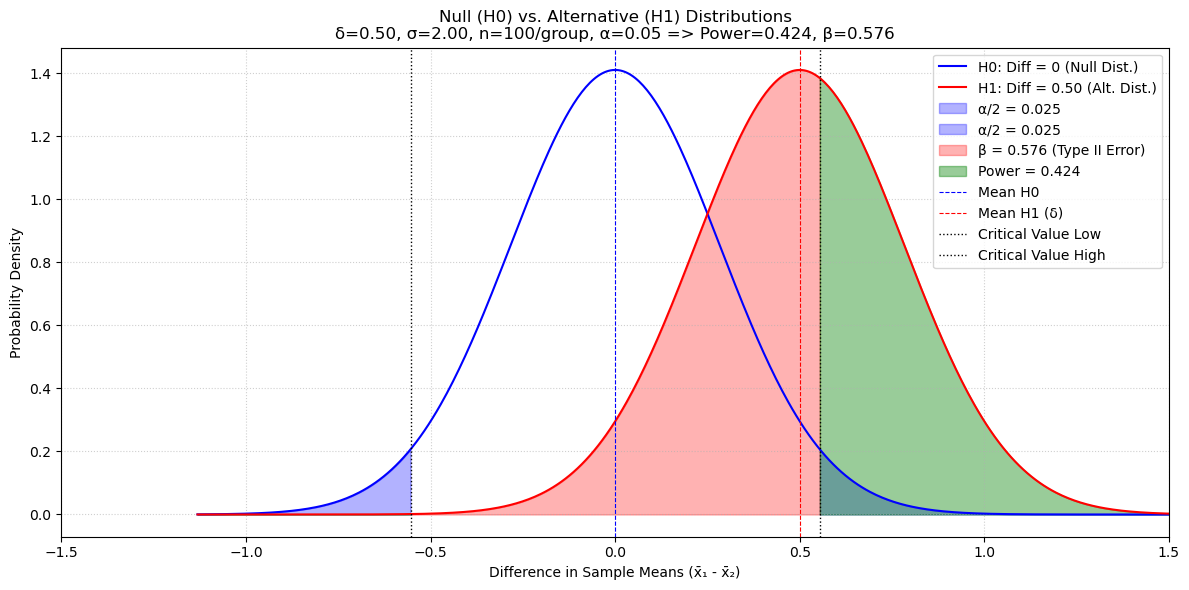

In [2]:


# --- Example Usage ---

# Scenario 1: Decent power
visualize_power(delta=0.5, sigma=2.0, n=100, alpha=0.05)

# Scenario 2: Low power (small effect size for the sample size)
# visualize_power(delta=0.2, sigma=2.0, n=100, alpha=0.05)

# Scenario 3: High power (large sample size)
# visualize_power(delta=0.5, sigma=2.0, n=500, alpha=0.05)

# Scenario 4: High power (large effect size)
# visualize_power(delta=1.0, sigma=2.0, n=100, alpha=0.05)

# Scenario 5: Higher alpha (more power, more Type I risk)
# visualize_power(delta=0.5, sigma=2.0, n=100, alpha=0.10)

# Scenario 6: Smaller sample size (less power)
# visualize_power(delta=0.5, sigma=2.0, n=30, alpha=0.05)

# Scenario 7: Negative effect size
# visualize_power(delta=-0.5, sigma=2.0, n=100, alpha=0.05)

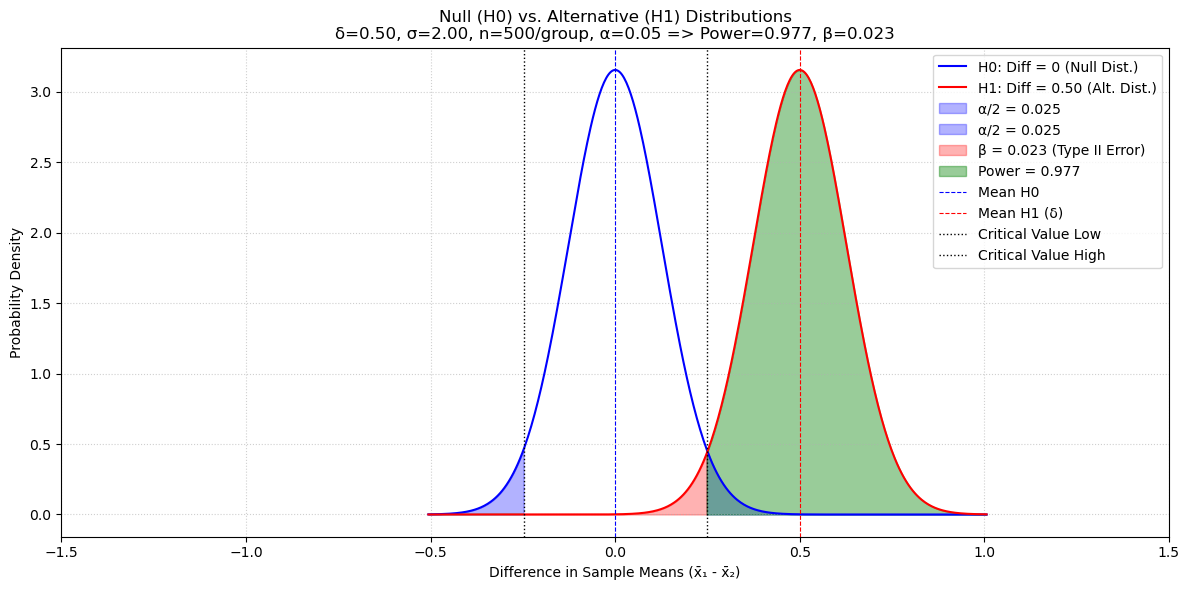

In [3]:

visualize_power(delta=0.5, sigma=2.0, n=500, alpha=0.05)